# GraphSAGE Document Classification on RVL-CDIP Small-200

This notebook loads cached ResNet-50 layer4 features (from Notebook 1), constructs spatial graphs,
trains a GraphSAGE classifier, and compares results with the ResNet-50 baseline.

**Inputs:** `cached_features/`, `checkpoints/resnet50_baseline_metrics.json`

---

## 1. Setup

In [10]:
import os
os.environ["PYTORCH_ENABLE_MPS_FALLBACK"] = "1"

import sys
sys.path.insert(0, "..")

import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch_geometric
from torch_geometric.loader import DataLoader as PyGDataLoader
from sklearn.metrics import classification_report, confusion_matrix
from tqdm import tqdm

from src.config import Config
from src.data import load_rvl_cdip, RVL_CDIP_LABELS
from src.features import load_cached_features
from src.graph import build_grid_edge_index, build_graph_dataset
from src.model import GraphSAGEClassifier

print(f"PyTorch: {torch.__version__}")
print(f"PyG: {torch_geometric.__version__}")

PyTorch: 2.11.0
PyG: 2.7.0


In [11]:
config = Config()
config.seed_everything()

CHECKPOINT_DIR = Path("../checkpoints")

# Load dataset metadata to populate RVL_CDIP_LABELS
_ = load_rvl_cdip(config)

print(f"\nLabels loaded: {len(RVL_CDIP_LABELS)} classes")
print(f"Device: {config.device}")

Device: mps
Mode: sample
Sample size: 100
Loading sample dataset: vaclavpechtor/rvl_cdip-small-200...


'[SSL: CERTIFICATE_VERIFY_FAILED] certificate verify failed: unable to get local issuer certificate (_ssl.c:1028)' thrown while requesting HEAD https://huggingface.co/datasets/vaclavpechtor/rvl_cdip-small-200/resolve/dfecd585c9b5c8fe56e8d7809d5b3cf710668dff/rvl_cdip-small-200.py
Retrying in 1s [Retry 1/5].
Using the latest cached version of the dataset since vaclavpechtor/rvl_cdip-small-200 couldn't be found on the Hugging Face Hub
Found the latest cached dataset configuration 'default' at .hf_cache/vaclavpechtor___rvl_cdip-small-200/default/0.0.0/dfecd585c9b5c8fe56e8d7809d5b3cf710668dff (last modified on Wed Mar 25 21:56:37 2026).


Loaded train: 2560 samples
Loaded validation: 640 samples

Labels loaded: 16 classes
Device: mps


## 2. Load Cached Features

Load the pre-extracted ResNet-50 layer4 features from Notebook 1.

In [12]:
cached_train = load_cached_features(config, "train")
cached_val = load_cached_features(config, "validation")

print(f"Train: {len(cached_train)} samples")
print(f"Val:   {len(cached_val)} samples")
print(f"Feature shape: {cached_train[0]['features'].shape}")
print(f"Label example: {cached_train[0]['label']} ({RVL_CDIP_LABELS[cached_train[0]['label']]})")

Loaded 2560 cached features from cached_features/train
Loaded 640 cached features from cached_features/validation
Train: 2560 samples
Val:   640 samples
Feature shape: torch.Size([2048, 7, 7])
Label example: 0 (advertisement)


## 3. Graph Construction

Convert each `[2048, 7, 7]` feature map into a graph:
- **49 nodes** (one per spatial position on the 7x7 grid)
- **2048-dim** features per node (channel values at that position)
- **k=8 edges** (Moore neighborhood: cardinal + diagonal neighbors)

The edge index is computed once since all images share the same 7x7 grid topology.

Grid: 7x7 = 49 nodes
k=8 neighbors (Moore neighborhood)
Edge index shape: torch.Size([2, 312]) (312 directed edges)


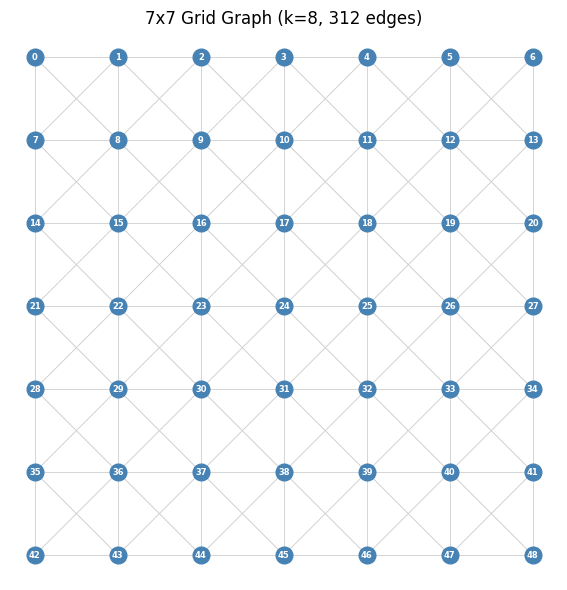

In [13]:
GRID_H, GRID_W = 7, 7
K_NEIGHBORS = 8

edge_index = build_grid_edge_index(GRID_H, GRID_W, k=K_NEIGHBORS)
print(f"Grid: {GRID_H}x{GRID_W} = {GRID_H * GRID_W} nodes")
print(f"k={K_NEIGHBORS} neighbors (Moore neighborhood)")
print(f"Edge index shape: {edge_index.shape} ({edge_index.shape[1]} directed edges)")

# Visualize grid graph
fig, ax = plt.subplots(figsize=(6, 6))

# Plot nodes
for row in range(GRID_H):
    for col in range(GRID_W):
        ax.plot(col, -row, "o", color="steelblue", markersize=12)
        ax.text(col, -row, str(row * GRID_W + col), ha="center", va="center",
                fontsize=6, color="white", fontweight="bold")

# Plot edges
src, dst = edge_index
for s, d in zip(src.tolist(), dst.tolist()):
    sr, sc = divmod(s, GRID_W)
    dr, dc = divmod(d, GRID_W)
    ax.plot([sc, dc], [-sr, -dr], "-", color="lightgray", linewidth=0.5, zorder=0)

ax.set_title(f"7x7 Grid Graph (k={K_NEIGHBORS}, {edge_index.shape[1]} edges)")
ax.set_aspect("equal")
ax.axis("off")
plt.tight_layout()
plt.show()

In [16]:
train_graphs = build_graph_dataset(cached_train, edge_index)
val_graphs = build_graph_dataset(cached_val, edge_index)

print(f"Train graphs: {len(train_graphs)}")
print(f"Val graphs:   {len(val_graphs)}")

g = train_graphs[0]
print(f"\nFirst graph:")
print(f"  x: {g.x.shape}")
print(f"  edge_index: {g.edge_index.shape}")
print(f"  y: {g.y.item()} ({RVL_CDIP_LABELS[g.y.item()]})")

Train graphs: 2560
Val graphs:   640

First graph:
  x: torch.Size([49, 2048])
  edge_index: torch.Size([2, 312])
  y: 0 (advertisement)


In [17]:
train_pyg_loader = PyGDataLoader(train_graphs, batch_size=config.batch_size, shuffle=True)
val_pyg_loader = PyGDataLoader(val_graphs, batch_size=config.batch_size, shuffle=False)

print(f"Train: {len(train_pyg_loader)} batches")
print(f"Val:   {len(val_pyg_loader)} batches")

# Inspect one batch
batch = next(iter(train_pyg_loader))
print(f"\nBatch structure:")
print(f"  batch.x: {batch.x.shape}")
print(f"  batch.edge_index: {batch.edge_index.shape}")
print(f"  batch.y: {batch.y.shape}")
print(f"  batch.batch: {batch.batch.shape} (unique graphs: {batch.batch.max().item() + 1})")

Train: 80 batches
Val:   20 batches

Batch structure:
  batch.x: torch.Size([1568, 2048])
  batch.edge_index: torch.Size([2, 9984])
  batch.y: torch.Size([32])
  batch.batch: torch.Size([1568]) (unique graphs: 32)


## 4. GraphSAGE Model

Two-layer GraphSAGE with global mean pooling:

```
SAGEConv(2048, 256) -> ReLU -> Dropout(0.5)
-> SAGEConv(256, 128) -> ReLU
-> global_mean_pool
-> Linear(128, 16)
```

In [18]:
IN_CHANNELS = 2048
HIDDEN_CHANNELS = 256
EMBED_CHANNELS = 128
DROPOUT = 0.5

gnn_model = GraphSAGEClassifier(
    in_channels=IN_CHANNELS,
    hidden_channels=HIDDEN_CHANNELS,
    embed_channels=EMBED_CHANNELS,
    num_classes=len(RVL_CDIP_LABELS),
    dropout=DROPOUT,
).to(config.device)

print(gnn_model)
print(f"\nTotal parameters: {sum(p.numel() for p in gnn_model.parameters()):,}")
print(f"Trainable: {sum(p.numel() for p in gnn_model.parameters() if p.requires_grad):,}")

GraphSAGEClassifier(
  (conv1): SAGEConv(2048, 256, aggr=mean)
  (conv2): SAGEConv(256, 128, aggr=mean)
  (classifier): Linear(in_features=128, out_features=16, bias=True)
  (dropout): Dropout(p=0.5, inplace=False)
  (relu): ReLU()
)

Total parameters: 1,116,560
Trainable: 1,116,560


## 5. Training

In [19]:
NUM_EPOCHS = 50
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 5e-4

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(
    gnn_model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
)

print(f"Epochs: {NUM_EPOCHS}")
print(f"Optimizer: Adam (lr={LEARNING_RATE}, weight_decay={WEIGHT_DECAY})")
print(f"Loss: CrossEntropyLoss")

Epochs: 50
Optimizer: Adam (lr=0.001, weight_decay=0.0005)
Loss: CrossEntropyLoss


In [20]:
history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
best_val_acc = 0.0
best_checkpoint_path = CHECKPOINT_DIR / "graphsage_best.pt"

for epoch in range(NUM_EPOCHS):
    # --- Train ---
    gnn_model.train()
    train_loss_sum = 0.0
    train_correct = 0
    train_total = 0

    for batch in train_pyg_loader:
        batch = batch.to(config.device)

        optimizer.zero_grad()
        out = gnn_model(batch.x, batch.edge_index, batch.batch)
        loss = criterion(out, batch.y)
        loss.backward()
        optimizer.step()

        train_loss_sum += loss.item() * batch.y.size(0)
        train_correct += (out.argmax(dim=1) == batch.y).sum().item()
        train_total += batch.y.size(0)

    train_loss = train_loss_sum / train_total
    train_acc = train_correct / train_total

    # --- Validate ---
    gnn_model.eval()
    val_loss_sum = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for batch in val_pyg_loader:
            batch = batch.to(config.device)
            out = gnn_model(batch.x, batch.edge_index, batch.batch)
            loss = criterion(out, batch.y)

            val_loss_sum += loss.item() * batch.y.size(0)
            val_correct += (out.argmax(dim=1) == batch.y).sum().item()
            val_total += batch.y.size(0)

    val_loss = val_loss_sum / val_total
    val_acc = val_correct / val_total

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)

    checkpoint_marker = ""
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(gnn_model.state_dict(), best_checkpoint_path)
        checkpoint_marker = " *"

    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(
            f"Epoch {epoch+1:02d}/{NUM_EPOCHS} | "
            f"Train Loss: {train_loss:.4f}  Acc: {train_acc:.4f} | "
            f"Val Loss: {val_loss:.4f}  Acc: {val_acc:.4f}{checkpoint_marker}"
        )

print(f"\nBest validation accuracy: {best_val_acc:.4f}")
print(f"Checkpoint saved to: {best_checkpoint_path}")

Epoch 01/50 | Train Loss: 0.5732  Acc: 0.8281 | Val Loss: 2.0342  Acc: 0.5922 *
Epoch 05/50 | Train Loss: 0.0280  Acc: 0.9918 | Val Loss: 3.0326  Acc: 0.6062 *
Epoch 10/50 | Train Loss: 0.0396  Acc: 0.9883 | Val Loss: 3.2002  Acc: 0.5906
Epoch 15/50 | Train Loss: 0.0693  Acc: 0.9766 | Val Loss: 2.9445  Acc: 0.6078 *
Epoch 20/50 | Train Loss: 0.0011  Acc: 1.0000 | Val Loss: 3.1012  Acc: 0.6000
Epoch 25/50 | Train Loss: 0.0756  Acc: 0.9793 | Val Loss: 2.5129  Acc: 0.5328
Epoch 30/50 | Train Loss: 0.0155  Acc: 0.9961 | Val Loss: 3.2893  Acc: 0.5922
Epoch 35/50 | Train Loss: 0.0009  Acc: 1.0000 | Val Loss: 3.0877  Acc: 0.6156
Epoch 40/50 | Train Loss: 0.1219  Acc: 0.9602 | Val Loss: 2.8601  Acc: 0.5687
Epoch 45/50 | Train Loss: 0.0103  Acc: 0.9973 | Val Loss: 3.2000  Acc: 0.6094
Epoch 50/50 | Train Loss: 0.0010  Acc: 1.0000 | Val Loss: 3.2607  Acc: 0.5984

Best validation accuracy: 0.6156
Checkpoint saved to: ../checkpoints/graphsage_best.pt


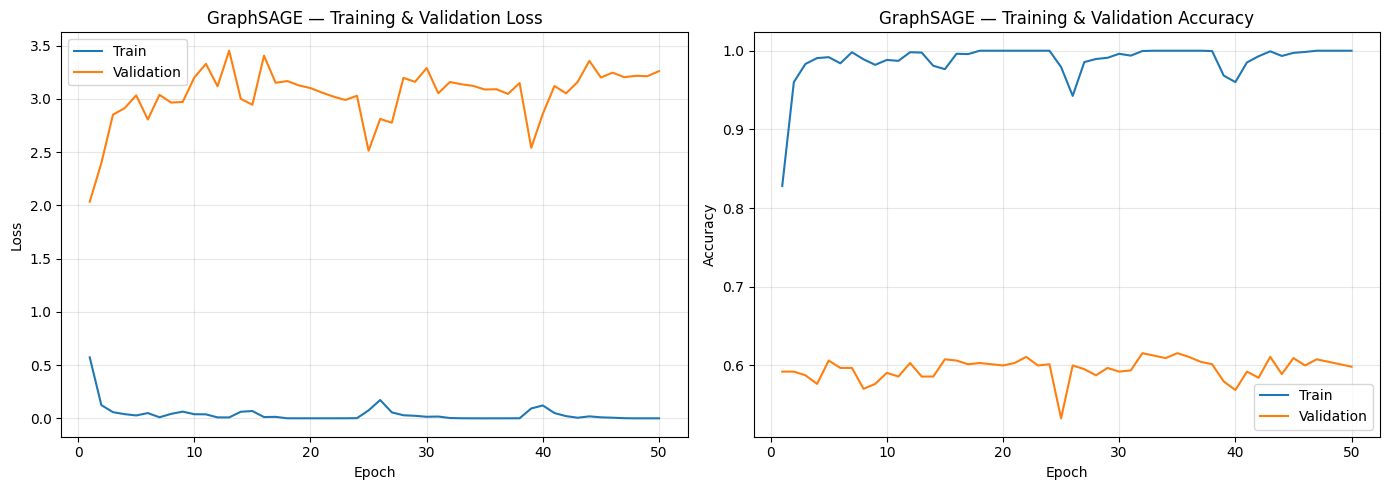

In [21]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

epochs_range = range(1, NUM_EPOCHS + 1)

ax1.plot(epochs_range, history["train_loss"], label="Train")
ax1.plot(epochs_range, history["val_loss"], label="Validation")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
ax1.set_title("GraphSAGE — Training & Validation Loss")
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(epochs_range, history["train_acc"], label="Train")
ax2.plot(epochs_range, history["val_acc"], label="Validation")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Accuracy")
ax2.set_title("GraphSAGE — Training & Validation Accuracy")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 6. Evaluation

In [22]:
gnn_model.load_state_dict(torch.load(best_checkpoint_path, weights_only=True))
gnn_model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for batch in val_pyg_loader:
        batch = batch.to(config.device)
        out = gnn_model(batch.x, batch.edge_index, batch.batch)
        preds = out.argmax(dim=1).cpu()
        all_preds.extend(preds.tolist())
        all_labels.extend(batch.y.cpu().tolist())

gnn_accuracy = sum(p == l for p, l in zip(all_preds, all_labels)) / len(all_labels)
print(f"GraphSAGE validation accuracy: {gnn_accuracy:.4f}")

GraphSAGE validation accuracy: 0.6156


In [23]:
report = classification_report(
    all_labels,
    all_preds,
    target_names=RVL_CDIP_LABELS,
    digits=4,
)
print(report)

                        precision    recall  f1-score   support

         advertisement     0.6522    0.7500    0.6977        40
                budget     0.5405    0.5000    0.5195        40
                 email     0.8250    0.8250    0.8250        40
           file_folder     0.9167    0.8250    0.8684        40
                  form     0.4286    0.3750    0.4000        40
           handwritten     0.7674    0.8250    0.7952        40
               invoice     0.4865    0.4500    0.4675        40
                letter     0.4906    0.6500    0.5591        40
                  memo     0.5217    0.6000    0.5581        40
          news_article     0.6970    0.5750    0.6301        40
          presentation     0.4565    0.5250    0.4884        40
         questionnaire     0.5385    0.5250    0.5316        40
                resume     0.8333    0.8750    0.8537        40
scientific_publication     0.7353    0.6250    0.6757        40
     scientific_report     0.4444    0.

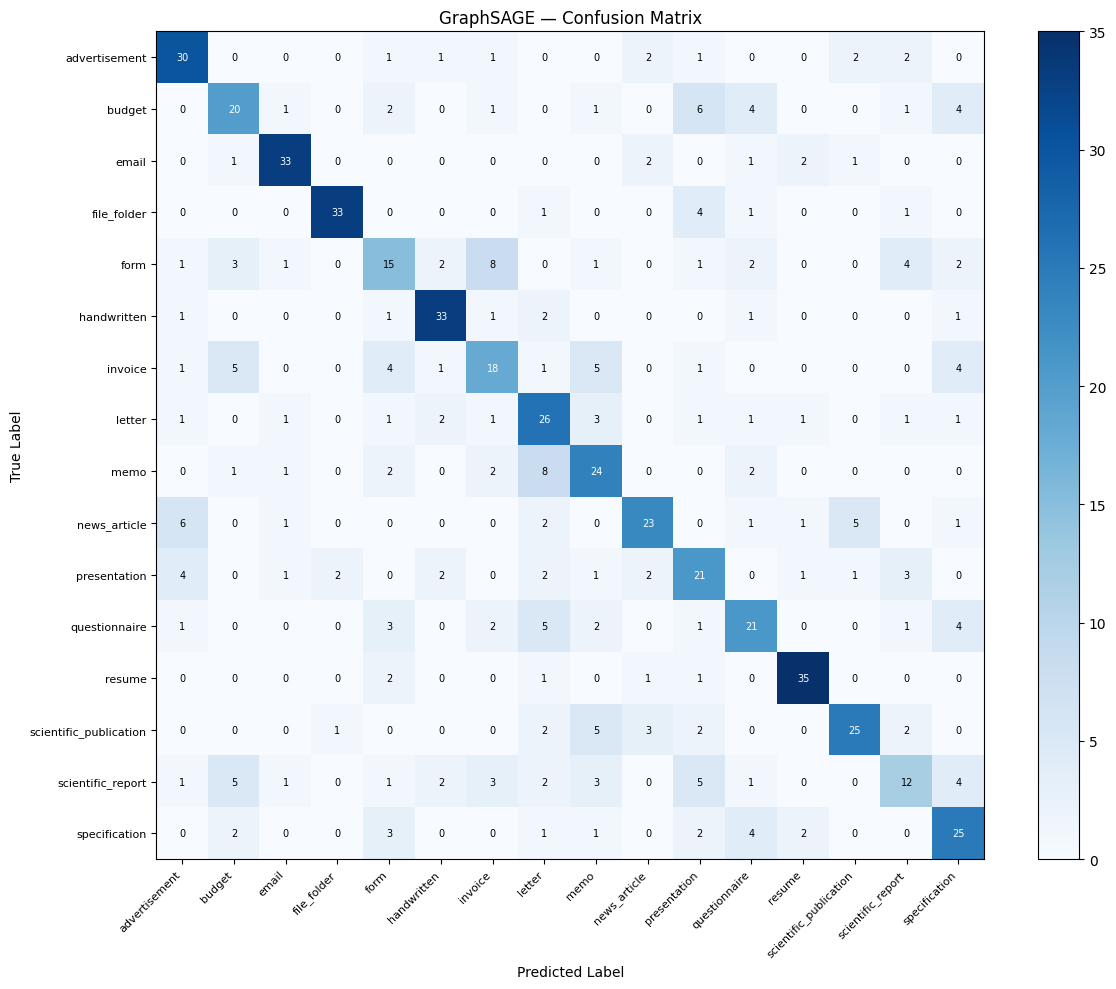

In [24]:
gnn_cm = confusion_matrix(all_labels, all_preds)

fig, ax = plt.subplots(figsize=(12, 10))
im = ax.imshow(gnn_cm, interpolation="nearest", cmap="Blues")
ax.set_title("GraphSAGE — Confusion Matrix")
plt.colorbar(im, ax=ax, fraction=0.046)

tick_marks = np.arange(len(RVL_CDIP_LABELS))
ax.set_xticks(tick_marks)
ax.set_xticklabels(RVL_CDIP_LABELS, rotation=45, ha="right", fontsize=8)
ax.set_yticks(tick_marks)
ax.set_yticklabels(RVL_CDIP_LABELS, fontsize=8)

thresh = gnn_cm.max() / 2.0
for i in range(gnn_cm.shape[0]):
    for j in range(gnn_cm.shape[1]):
        ax.text(
            j, i, str(gnn_cm[i, j]),
            ha="center", va="center",
            color="white" if gnn_cm[i, j] > thresh else "black",
            fontsize=7,
        )

ax.set_ylabel("True Label")
ax.set_xlabel("Predicted Label")
plt.tight_layout()
plt.show()

## 7. Comparison with ResNet-50 Baseline

In [25]:
baseline_metrics_path = CHECKPOINT_DIR / "resnet50_baseline_metrics.json"
with open(baseline_metrics_path) as f:
    baseline_metrics = json.load(f)

print(f"Baseline accuracy: {baseline_metrics['accuracy']:.4f}")
print(f"GraphSAGE accuracy: {gnn_accuracy:.4f}")
print(f"Difference: {gnn_accuracy - baseline_metrics['accuracy']:+.4f}")

Baseline accuracy: 0.6359
GraphSAGE accuracy: 0.6156
Difference: -0.0203


In [26]:
# Side-by-side per-class accuracy comparison
gnn_report_dict = classification_report(
    all_labels, all_preds, target_names=RVL_CDIP_LABELS, output_dict=True
)

print(f"{'Class':<25} {'Baseline F1':>12} {'GraphSAGE F1':>13} {'Delta':>8}")
print("-" * 60)

for label in RVL_CDIP_LABELS:
    b_f1 = baseline_metrics["per_class"][label]["f1"]
    g_f1 = gnn_report_dict[label]["f1-score"]
    delta = g_f1 - b_f1
    print(f"{label:<25} {b_f1:>12.4f} {g_f1:>13.4f} {delta:>+8.4f}")

print("-" * 60)
b_macro = baseline_metrics["macro_avg"]["f1"]
g_macro = gnn_report_dict["macro avg"]["f1-score"]
print(f"{'Macro Average':<25} {b_macro:>12.4f} {g_macro:>13.4f} {g_macro - b_macro:>+8.4f}")

Class                      Baseline F1  GraphSAGE F1    Delta
------------------------------------------------------------
advertisement                   0.7143        0.6977  -0.0166
budget                          0.5806        0.5195  -0.0612
email                           0.8095        0.8250  +0.0155
file_folder                     0.8395        0.8684  +0.0289
form                            0.4507        0.4000  -0.0507
handwritten                     0.8049        0.7952  -0.0097
invoice                         0.5070        0.4675  -0.0395
letter                          0.5814        0.5591  -0.0223
memo                            0.4935        0.5581  +0.0646
news_article                    0.6571        0.6301  -0.0270
presentation                    0.6000        0.4884  -0.1116
questionnaire                   0.5316        0.5316  +0.0000
resume                          0.8780        0.8537  -0.0244
scientific_publication          0.6923        0.6757  -0.0166
scientifi

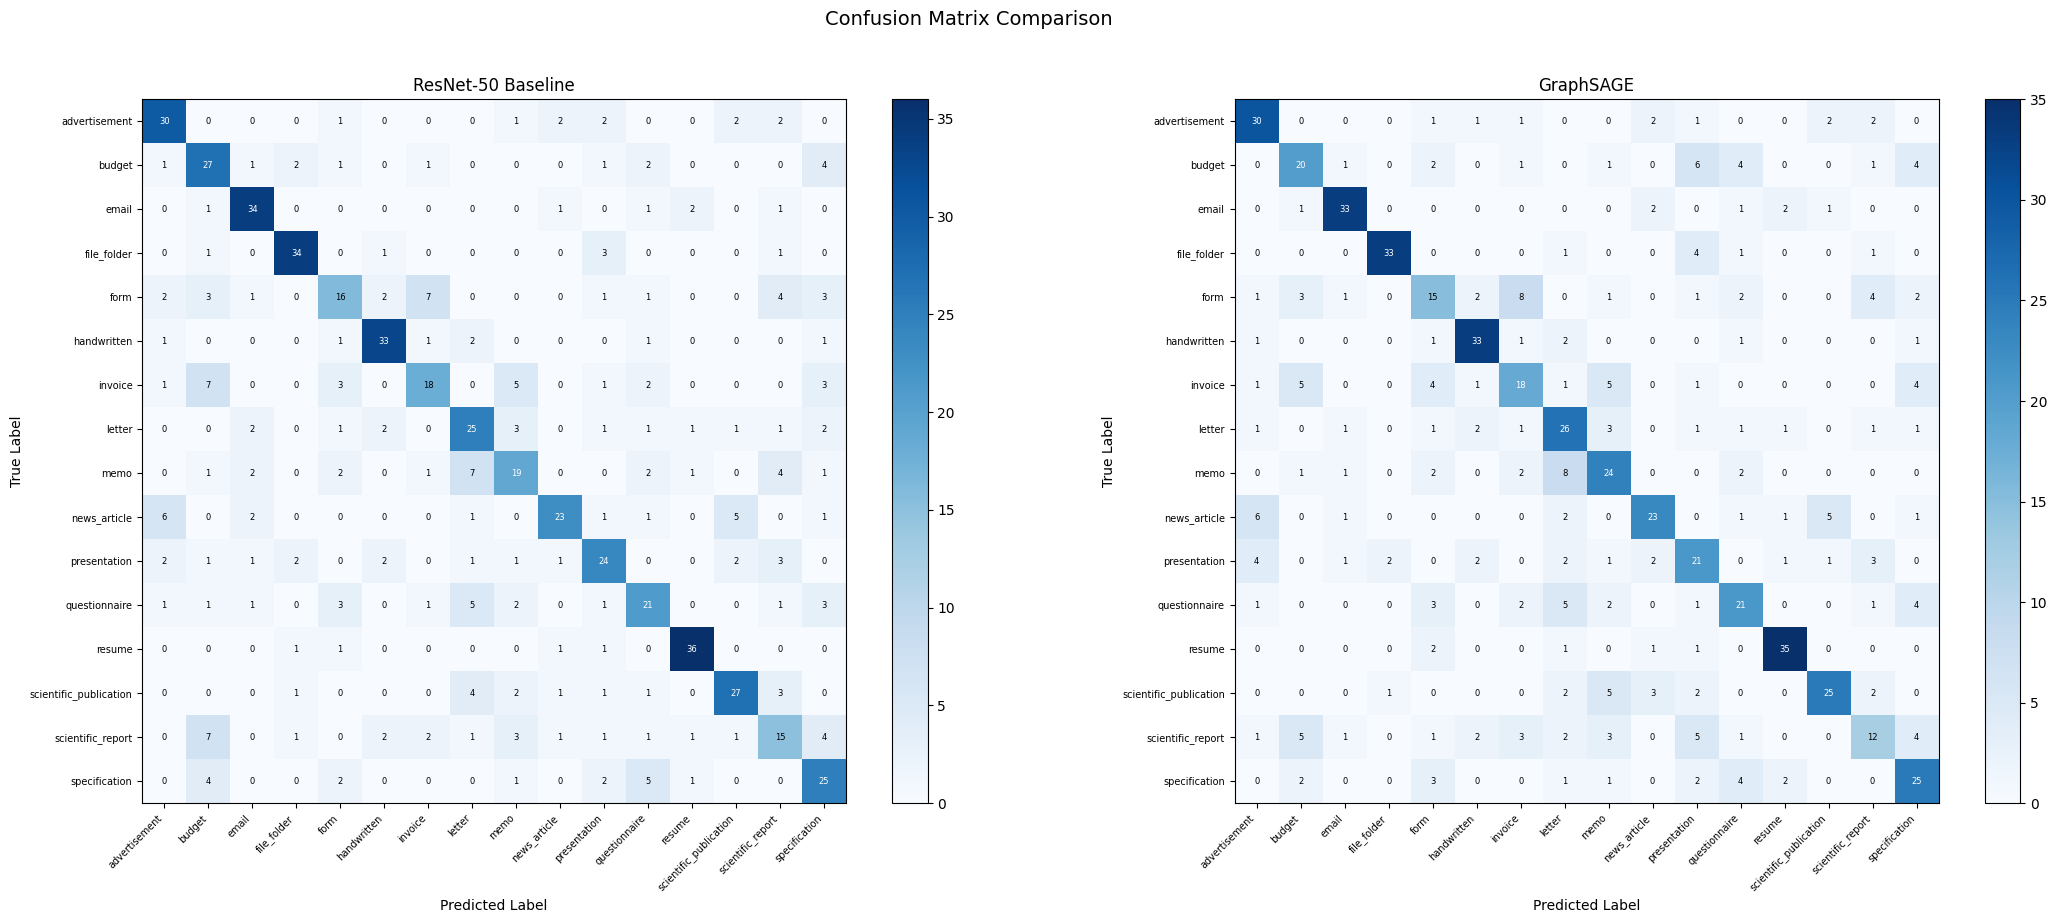

In [27]:
# Comparative confusion matrices side by side
baseline_cm = np.array(baseline_metrics["confusion_matrix"])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(22, 9))

for ax, cm_data, title in [
    (ax1, baseline_cm, "ResNet-50 Baseline"),
    (ax2, gnn_cm, "GraphSAGE"),
]:
    im = ax.imshow(cm_data, interpolation="nearest", cmap="Blues")
    ax.set_title(title)
    plt.colorbar(im, ax=ax, fraction=0.046)

    tick_marks = np.arange(len(RVL_CDIP_LABELS))
    ax.set_xticks(tick_marks)
    ax.set_xticklabels(RVL_CDIP_LABELS, rotation=45, ha="right", fontsize=7)
    ax.set_yticks(tick_marks)
    ax.set_yticklabels(RVL_CDIP_LABELS, fontsize=7)

    thresh = cm_data.max() / 2.0
    for i in range(cm_data.shape[0]):
        for j in range(cm_data.shape[1]):
            ax.text(
                j, i, str(cm_data[i, j]),
                ha="center", va="center",
                color="white" if cm_data[i, j] > thresh else "black",
                fontsize=6,
            )

    ax.set_ylabel("True Label")
    ax.set_xlabel("Predicted Label")

plt.suptitle("Confusion Matrix Comparison", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

In [28]:
gnn_metrics = {
    "model": "graphsage",
    "accuracy": gnn_accuracy,
    "per_class": {
        label: {
            "precision": gnn_report_dict[label]["precision"],
            "recall": gnn_report_dict[label]["recall"],
            "f1": gnn_report_dict[label]["f1-score"],
            "support": gnn_report_dict[label]["support"],
        }
        for label in RVL_CDIP_LABELS
    },
    "macro_avg": {
        "precision": gnn_report_dict["macro avg"]["precision"],
        "recall": gnn_report_dict["macro avg"]["recall"],
        "f1": gnn_report_dict["macro avg"]["f1-score"],
    },
    "confusion_matrix": gnn_cm.tolist(),
    "history": history,
    "graph_config": {
        "grid": f"{GRID_H}x{GRID_W}",
        "k_neighbors": K_NEIGHBORS,
        "num_nodes": GRID_H * GRID_W,
        "num_edges": edge_index.shape[1],
    },
}

gnn_metrics_path = CHECKPOINT_DIR / "graphsage_metrics.json"
with open(gnn_metrics_path, "w") as f:
    json.dump(gnn_metrics, f, indent=2)

print(f"GraphSAGE metrics saved to: {gnn_metrics_path}")
print(f"Accuracy: {gnn_metrics['accuracy']:.4f}")
print(f"Macro F1: {gnn_metrics['macro_avg']['f1']:.4f}")

GraphSAGE metrics saved to: ../checkpoints/graphsage_metrics.json
Accuracy: 0.6156
Macro F1: 0.6131


## Summary

| Model | Val Accuracy | Macro F1 | Parameters |
|-------|-------------|----------|------------|
| ResNet-50 (head-only) | see above | see above | ~32K trainable |
| GraphSAGE (2-layer) | see above | see above | ~1.1M |

**Key observations:**
- The ResNet-50 baseline uses global average pooling, collapsing spatial information into a single 2048-dim vector
- GraphSAGE preserves the 7x7 spatial layout and learns spatial relationships via message passing
- The comparison reveals whether spatial graph structure adds value for document classification

**Next steps:**
- Compare additional GNN architectures (GCN, GAT) in Notebook 3
- Ablation studies on k-NN parameter and network depth
- Evaluation on RVL-CDIP-N (out-of-distribution)